# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Social Media Impact on Real Life Dataset](https://www.kaggle.com/datasets/gauravjhaeigenvector/social-media-impact-on-real-life)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/gauravjhaeigenvector/social-media-impact-on-real-life/Social_media_impact_on_life (1).csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Social_media_impact_on_life (1).csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact,Age_Group,Usage_to_Sleep_Ratio,Wellbeing_Index,Is_Heavy_User,Sleep_Deficit
0,232,21,Male,Undergraduate,Other,4.1,Facebook,No,6.7,6.7,Neutral,Young Adult,0.61,6.14,No,Yes
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.7,7.6,Positive,Adult,0.18,8.43,No,No
2,788,22,Male,Graduate,Canada,4.7,Instagram,No,6.9,7.2,Neutral,Young Adult,0.68,6.36,No,Yes
3,686,18,Male,Undergraduate,Other,7.2,Snapchat,Yes,5.4,5.2,Negative,Teen,1.33,3.66,Yes,Yes
4,608,24,Female,High School,Other,7.5,Facebook,Yes,4.9,4.3,Negative,Adult,1.53,2.78,Yes,Yes


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact,Age_Group,Usage_to_Sleep_Ratio,Wellbeing_Index,Is_Heavy_User,Sleep_Deficit
1700,701,20,Female,Undergraduate,Italy,4.8,TikTok,No,6.9,7.0,Positive,Young Adult,0.70,6.21,No,Yes
1701,702,23,Male,Graduate,Russia,6.9,Instagram,Yes,6.0,4.3,Negative,Adult,1.15,3.51,Yes,Yes
1702,703,21,Female,Undergraduate,China,5.7,WeChat,Yes,6.7,6.0,Negative,Young Adult,0.85,5.24,Yes,Yes
1703,704,24,Male,Graduate,Japan,4.5,Twitter,No,7.5,7.9,Positive,Adult,0.60,7.14,No,No
1704,705,19,Female,Undergraduate,Poland,6.3,Facebook,Yes,6.5,5.0,Negative,Young Adult,0.97,4.36,Yes,Yes


## Shape of our dataset

In [5]:
df.shape

(1705, 16)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Overall_Impact', 'Age_Group',
       'Usage_to_Sleep_Ratio', 'Wellbeing_Index', 'Is_Heavy_User',
       'Sleep_Deficit'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score             float64
Overall_Impact                   object
Age_Group                        object
Usage_to_Sleep_Ratio            float64
Wellbeing_Index                 float64
Is_Heavy_User                    object
Sleep_Deficit                    object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
 11  Age_Group                     1705 non-null   object 
 12  Usage_to_Sleep_Ratio          1705 non-null   float64
 13  Wel

## Check Null Value

In [9]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
Age_Group                       0
Usage_to_Sleep_Ratio            0
Wellbeing_Index                 0
Is_Heavy_User                   0
Sleep_Deficit                   0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Usage_to_Sleep_Ratio,Wellbeing_Index
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.110909,6.598534,6.211672,0.841249,5.492997
std,267.058174,1.758557,1.680228,1.206469,1.289493,0.401928,1.754652
min,1.000000,18.000000,1.300000,3.800000,3.800000,0.160000,2.240000
25%,214.000000,19.000000,3.800000,5.600000,5.100000,0.510000,3.890000
50%,427.000000,21.000000,5.100000,6.600000,6.100000,0.780000,5.490000
75%,640.000000,22.000000,6.400000,7.500000,7.100000,1.150000,6.930000
max,1000.000000,24.000000,8.800000,9.700000,9.200000,2.320000,9.230000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

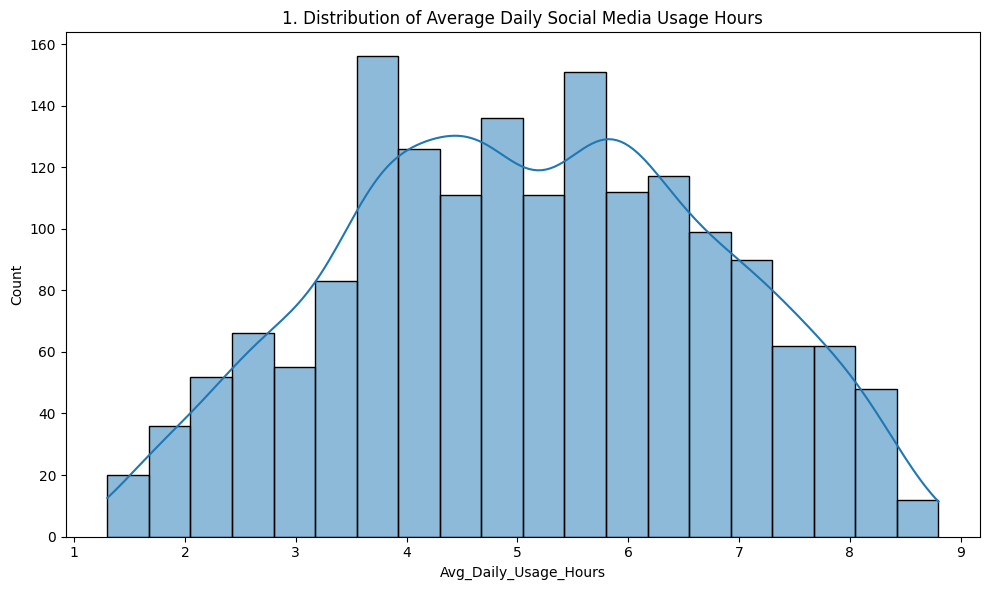

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Avg_Daily_Usage_Hours'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Average Daily Social Media Usage Hours')
show_fig()
plot_no += 1

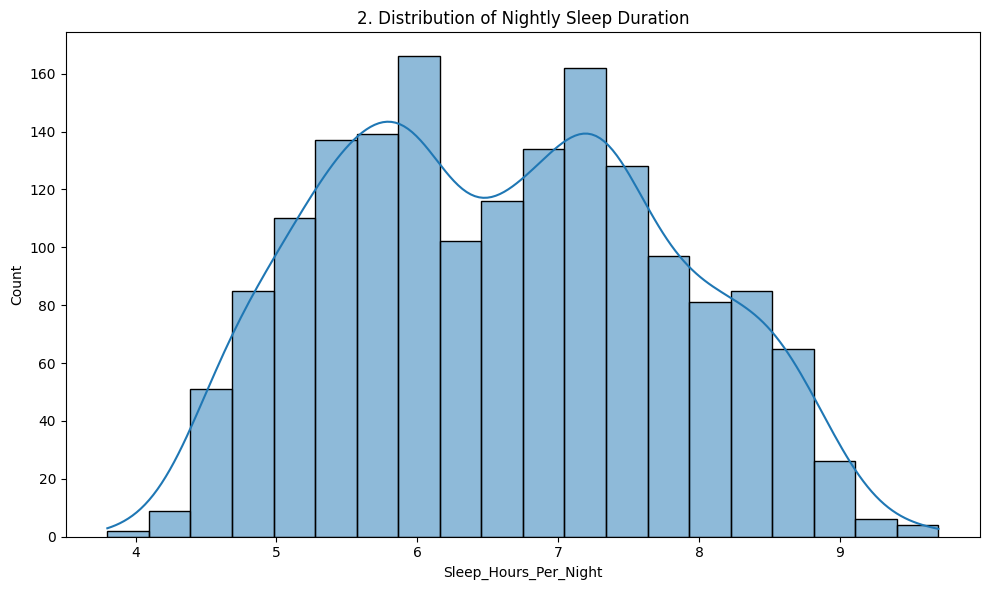

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Sleep_Hours_Per_Night'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Nightly Sleep Duration')
show_fig()
plot_no += 1

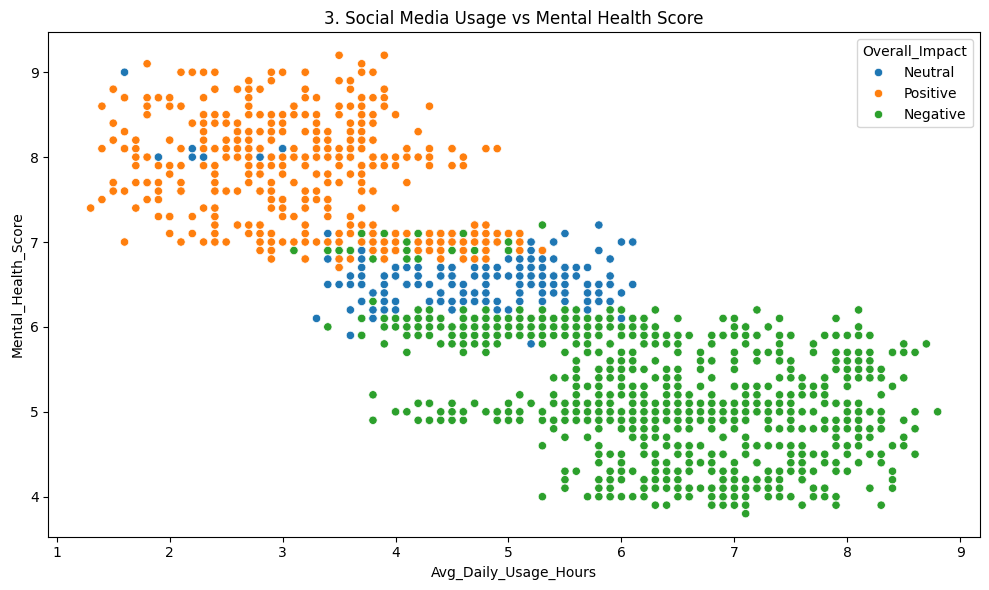

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', hue='Overall_Impact')
plt.title(f'{plot_no}. Social Media Usage vs Mental Health Score')
show_fig()
plot_no += 1

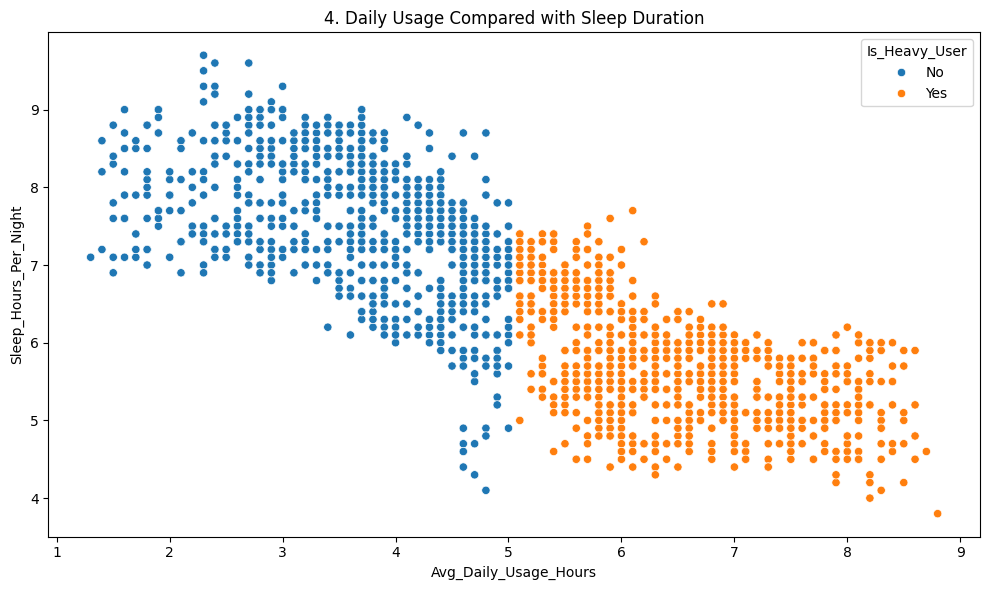

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', hue='Is_Heavy_User')
plt.title(f'{plot_no}. Daily Usage Compared with Sleep Duration')
show_fig()
plot_no += 1

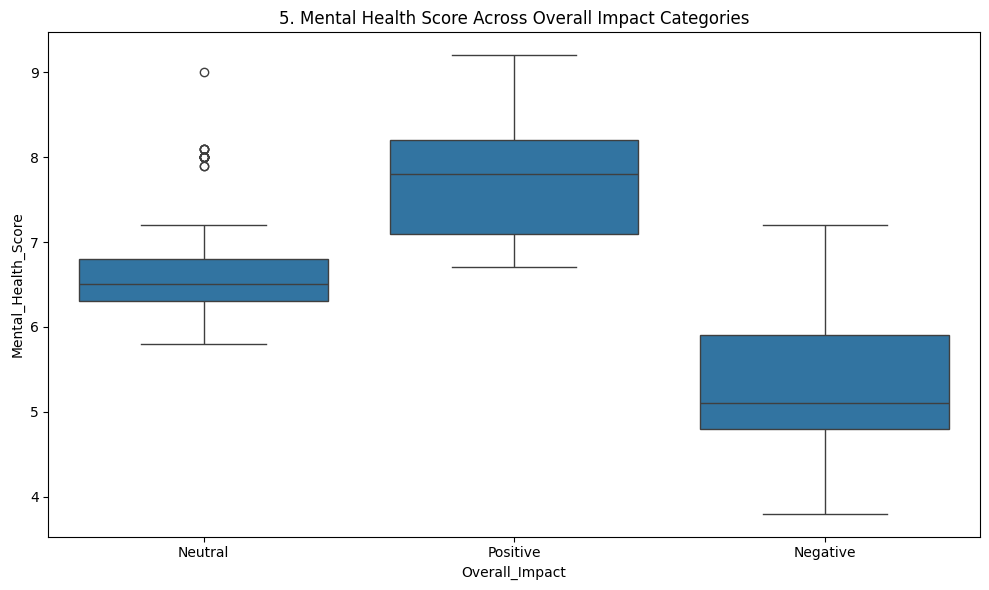

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Overall_Impact', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health Score Across Overall Impact Categories')
show_fig()
plot_no += 1

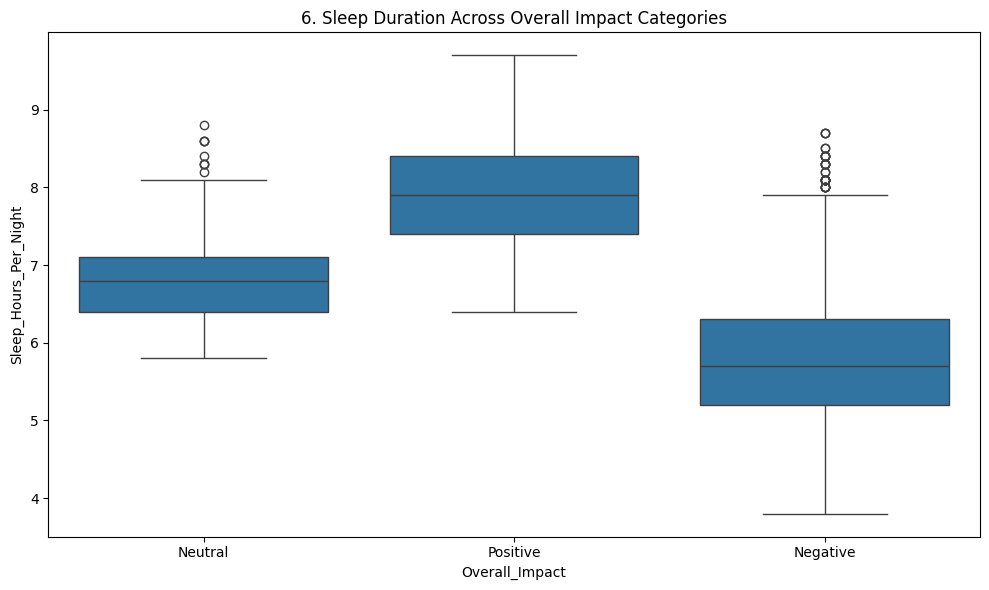

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Overall_Impact', y='Sleep_Hours_Per_Night')
plt.title(f'{plot_no}. Sleep Duration Across Overall Impact Categories')
show_fig()
plot_no += 1

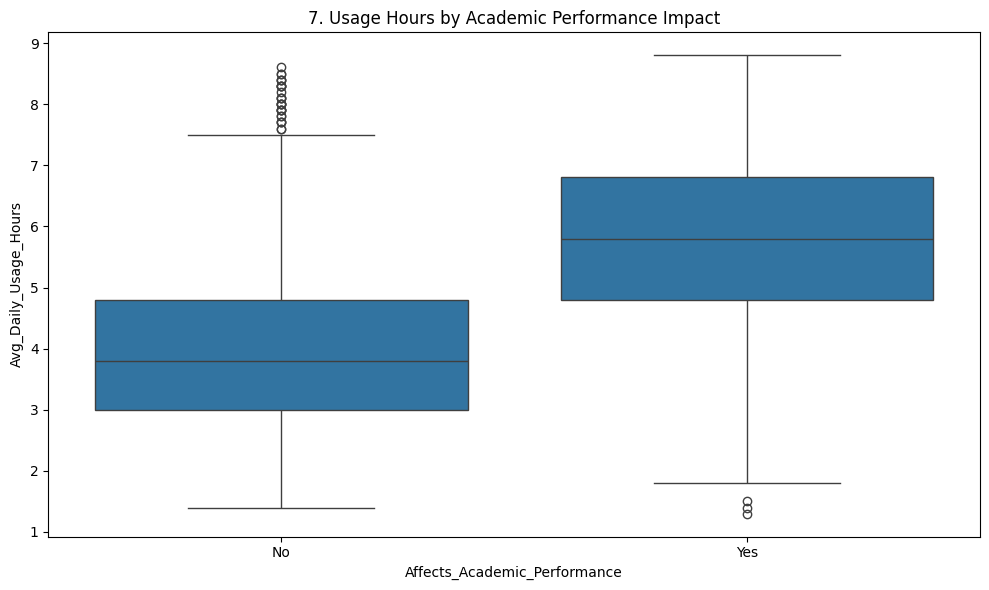

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Affects_Academic_Performance', y='Avg_Daily_Usage_Hours')
plt.title(f'{plot_no}. Usage Hours by Academic Performance Impact')
show_fig()
plot_no += 1

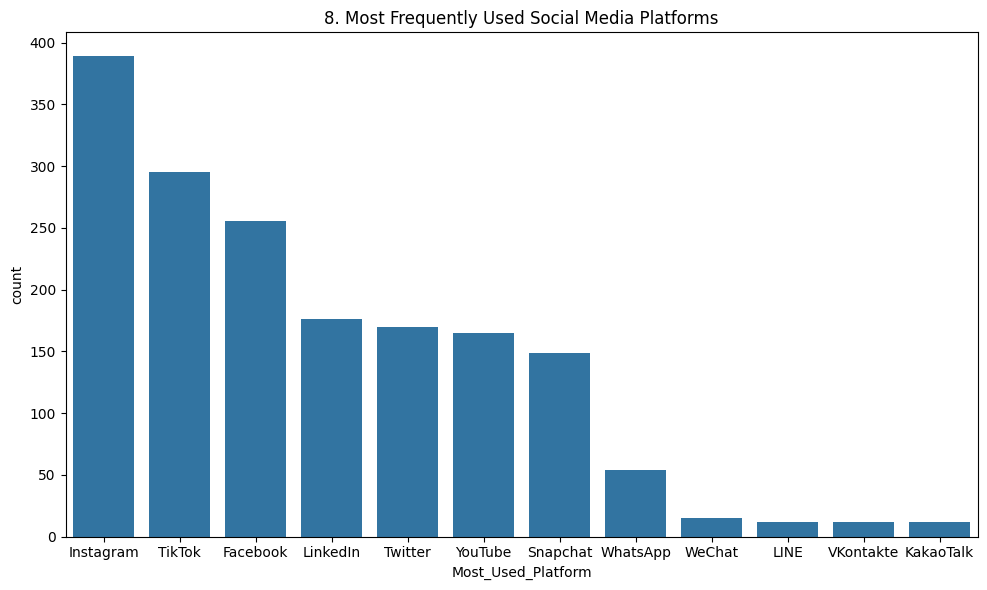

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Most_Used_Platform', order=df['Most_Used_Platform'].value_counts().index)
plt.title(f'{plot_no}. Most Frequently Used Social Media Platforms')
show_fig()
plot_no += 1

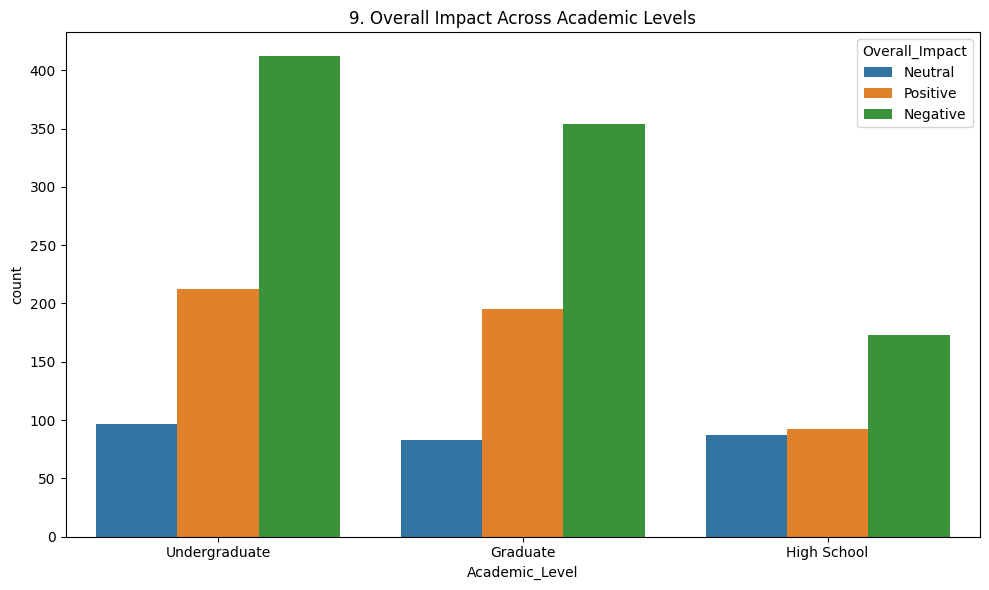

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Academic_Level', hue='Overall_Impact')
plt.title(f'{plot_no}. Overall Impact Across Academic Levels')
show_fig()
plot_no += 1

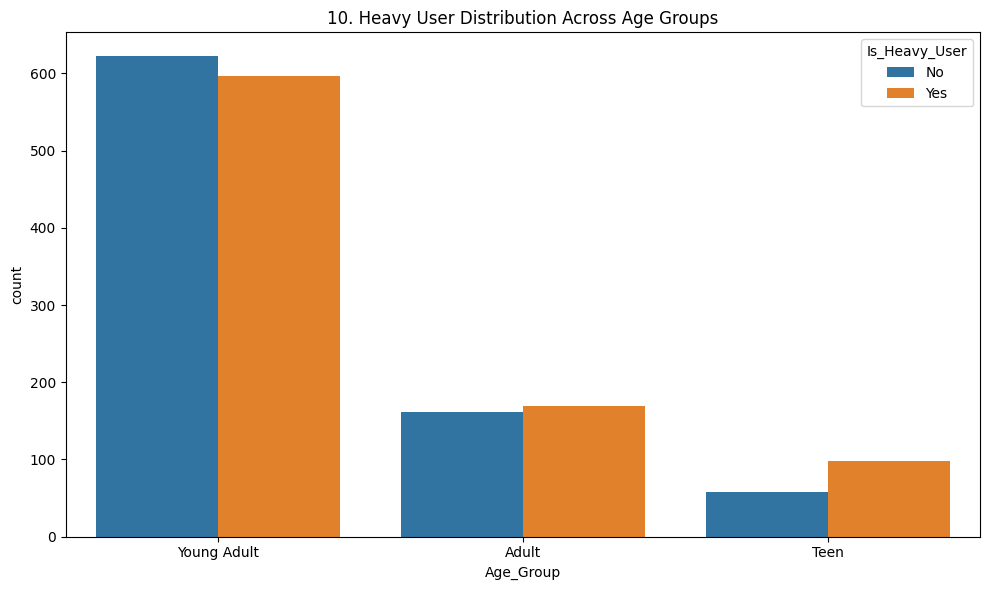

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Age_Group', hue='Is_Heavy_User')
plt.title(f'{plot_no}. Heavy User Distribution Across Age Groups')
show_fig()
plot_no += 1

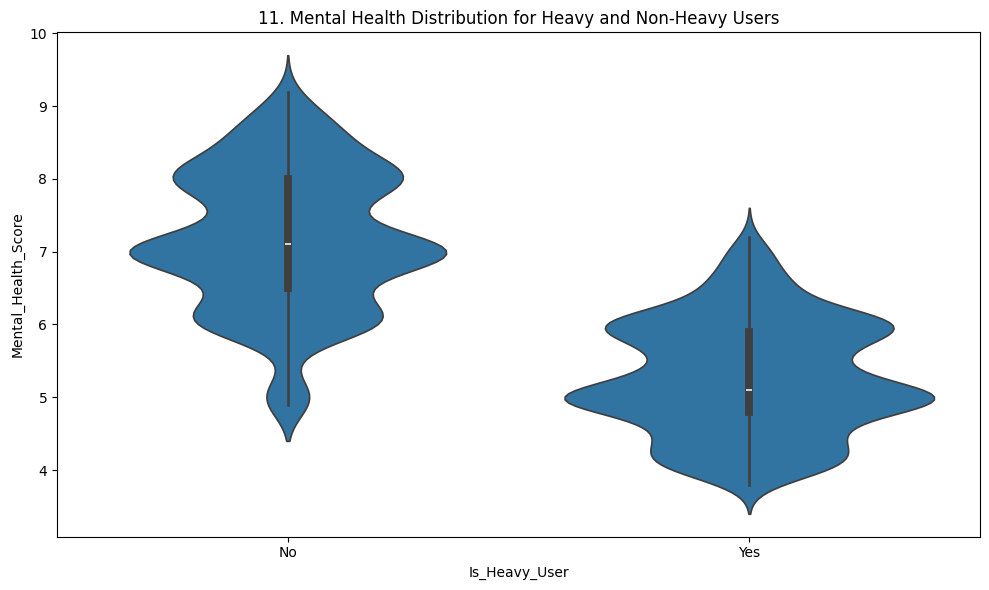

In [23]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Is_Heavy_User', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health Distribution for Heavy and Non-Heavy Users')
show_fig()
plot_no += 1

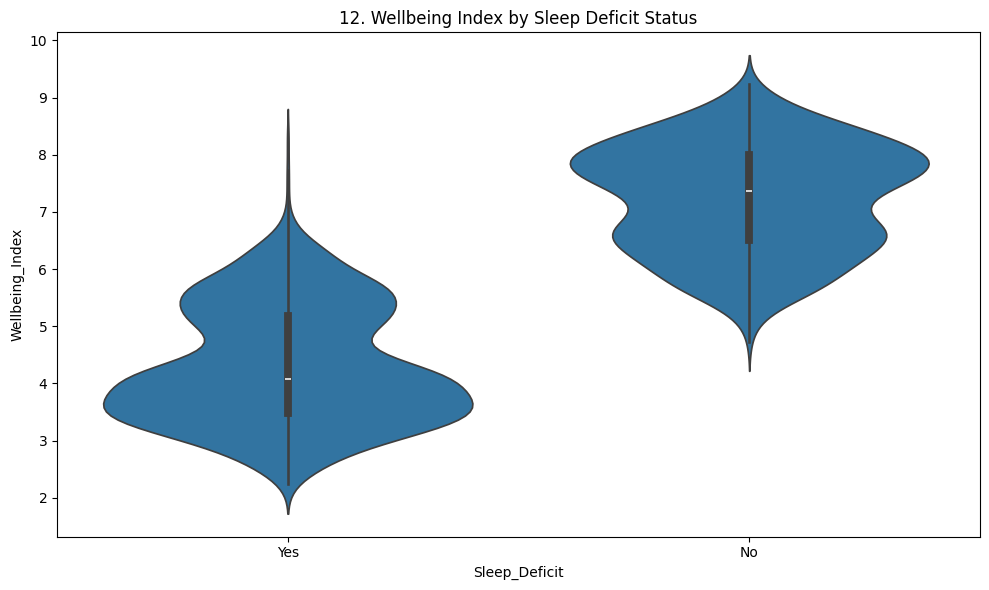

In [24]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Sleep_Deficit', y='Wellbeing_Index')
plt.title(f'{plot_no}. Wellbeing Index by Sleep Deficit Status')
show_fig()
plot_no += 1

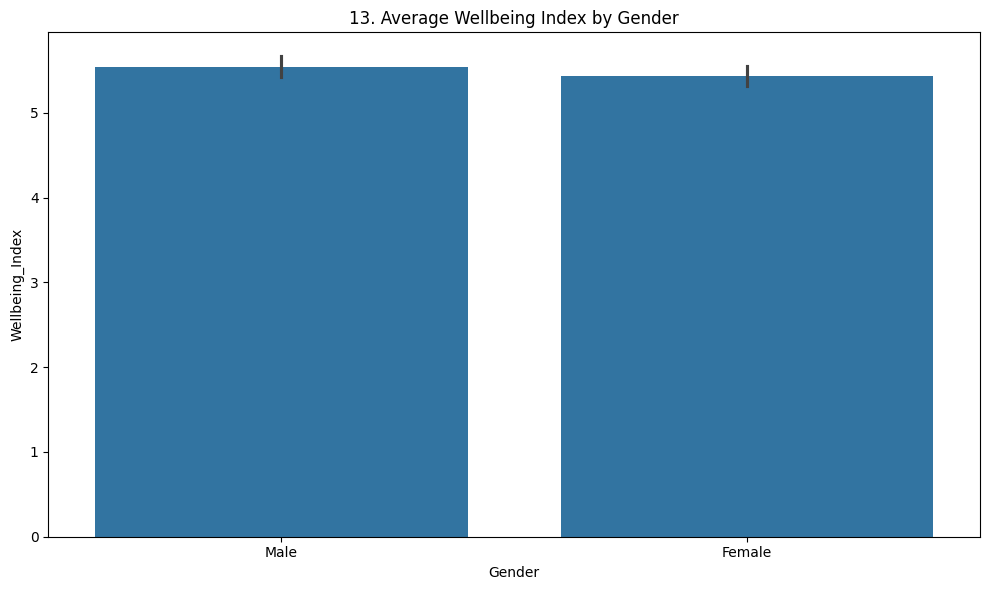

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Gender', y='Wellbeing_Index', estimator='mean')
plt.title(f'{plot_no}. Average Wellbeing Index by Gender')
show_fig()
plot_no += 1

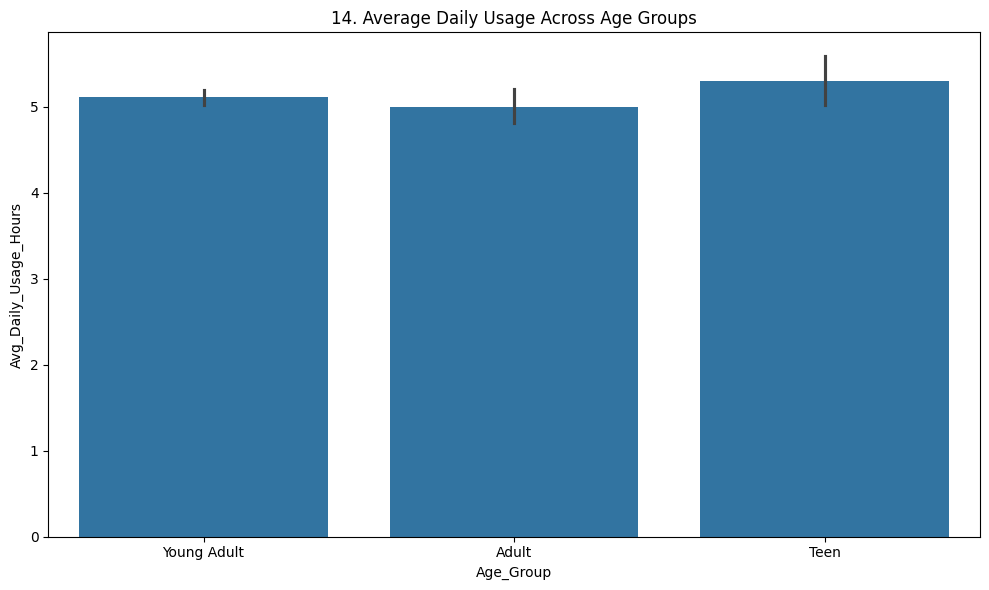

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Age_Group', y='Avg_Daily_Usage_Hours', estimator='mean')
plt.title(f'{plot_no}. Average Daily Usage Across Age Groups')
show_fig()
plot_no += 1

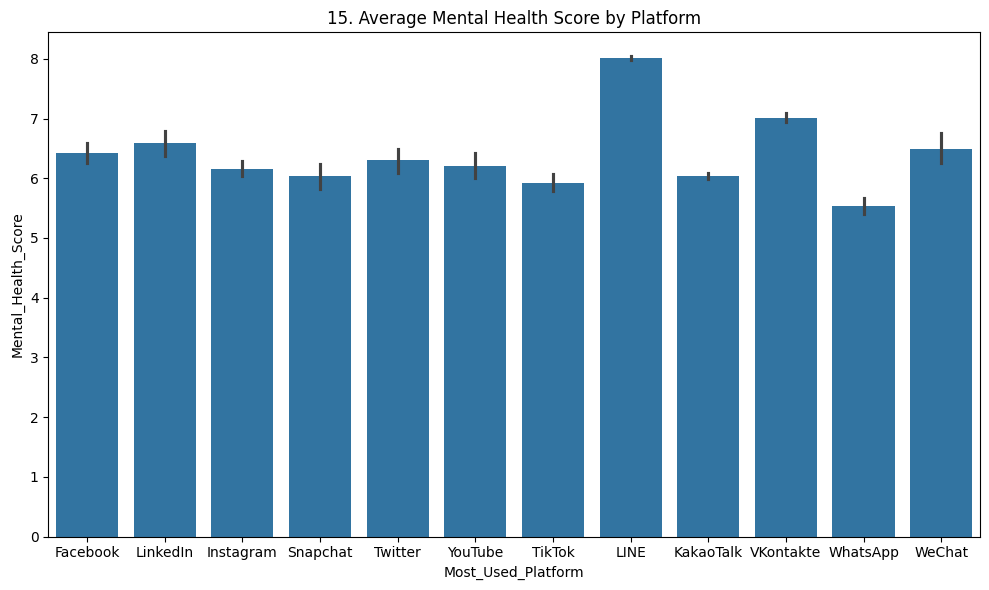

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Most_Used_Platform', y='Mental_Health_Score', estimator='mean')
plt.title(f'{plot_no}. Average Mental Health Score by Platform')
show_fig()
plot_no += 1

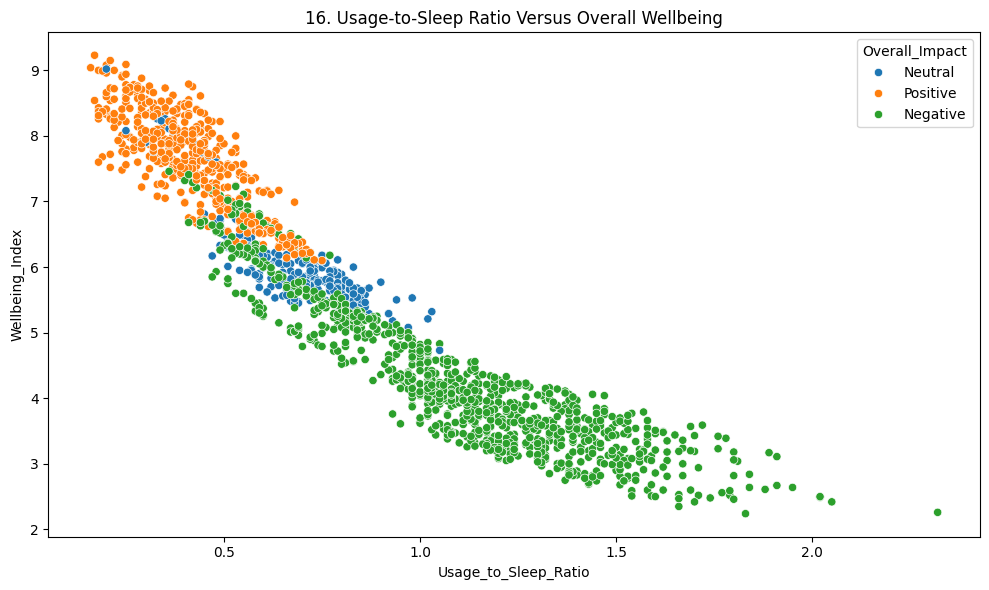

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Usage_to_Sleep_Ratio', y='Wellbeing_Index', hue='Overall_Impact')
plt.title(f'{plot_no}. Usage-to-Sleep Ratio Versus Overall Wellbeing')
show_fig()
plot_no += 1

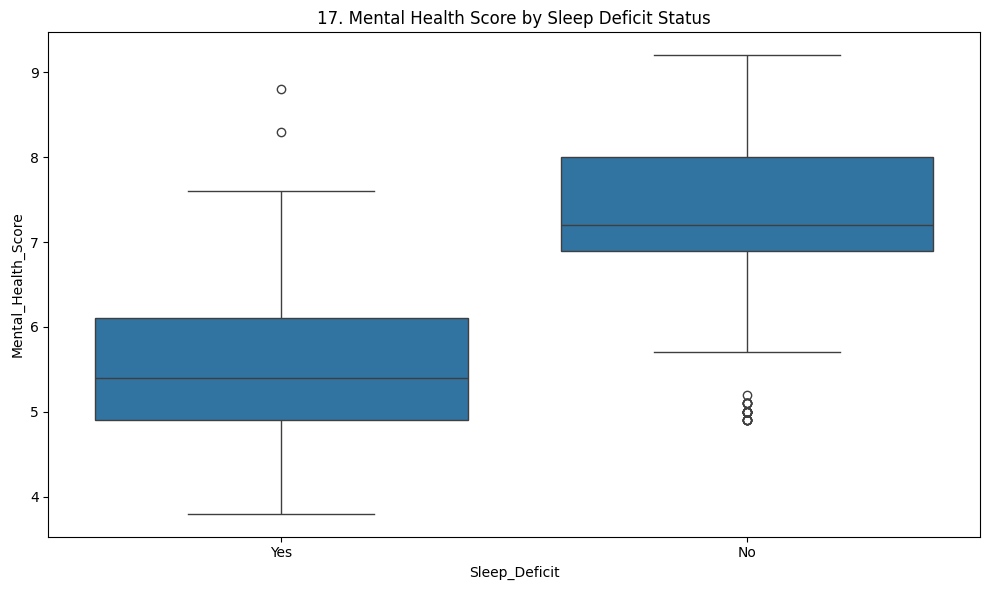

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Sleep_Deficit', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health Score by Sleep Deficit Status')
show_fig()
plot_no += 1

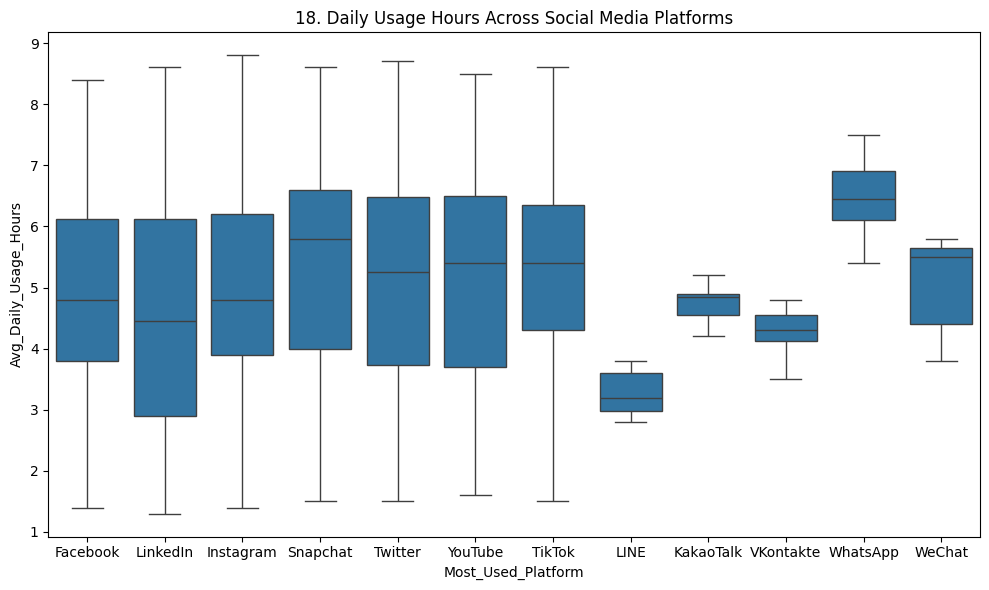

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Most_Used_Platform', y='Avg_Daily_Usage_Hours')
plt.title(f'{plot_no}. Daily Usage Hours Across Social Media Platforms')
show_fig()
plot_no += 1

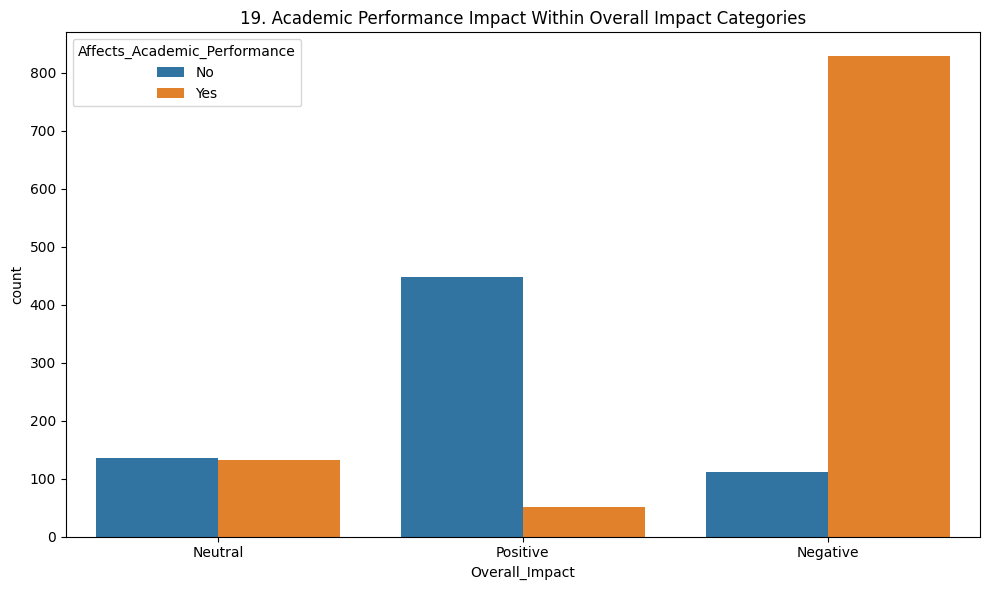

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Overall_Impact', hue='Affects_Academic_Performance')
plt.title(f'{plot_no}. Academic Performance Impact Within Overall Impact Categories')
show_fig()
plot_no += 1

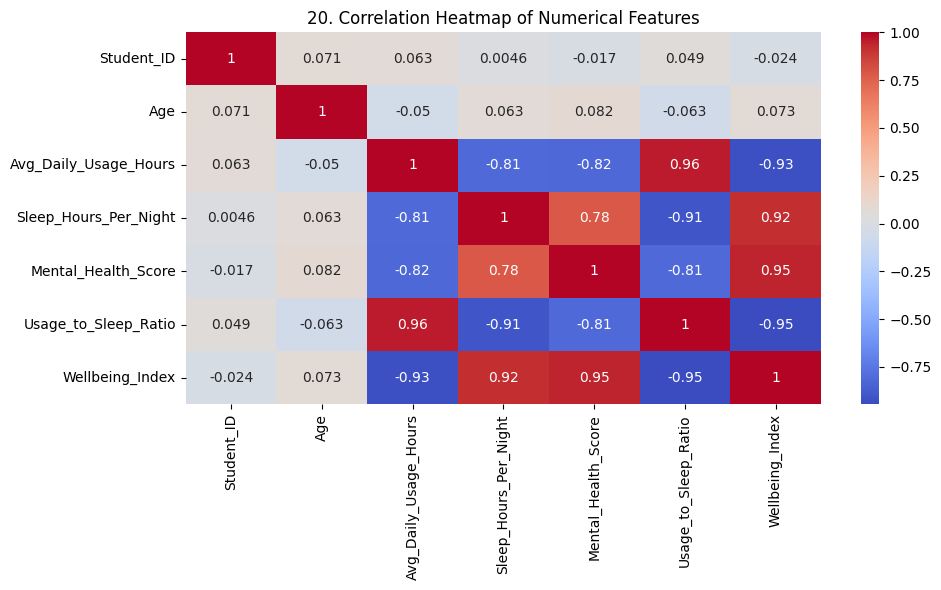

In [32]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of dataframe

In [33]:
data = df.copy()

## Encode categorical columns

In [34]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

## Define features and target

In [35]:
X = data.drop('Overall_Impact', axis=1)
y = data['Overall_Impact']

## Split dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Create model with scaling

In [37]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

## Train model

In [38]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('classifier', SVC())])

## Predict test data

In [39]:
y_pred = model.predict(X_test)

## Print accuracy

In [40]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9413489736070382


## Plot confusion matrix

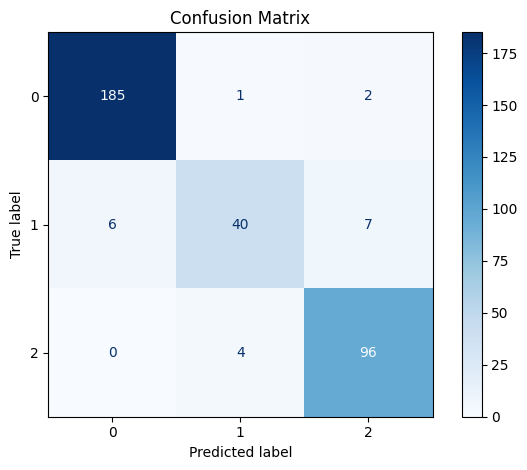

In [41]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()